In [1]:

# Let me start by examining the available artifact and setting up the computational environment
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from collections import defaultdict
import pandas as pd
from tqdm import tqdm

# Load the omega values artifact
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values = pickle.load(f)

print(f"Loaded omega_values array with shape: {omega_values.shape}")
print(f"Data type: {omega_values.dtype}")
print(f"First 20 values: {omega_values[:20]}")


Loaded omega_values array with shape: (1000000,)
Data type: int64
First 20 values: [0 1 1 2 1 2 1 3 2 2 1 3 1 2 2 4 1 3 1 3]


In [2]:

# Define the analysis plan and core computational infrastructure

"""
ANALYSIS PLAN:
=============
1. Set N=10^6, generate a grid of 500 t-values in [10^6, 2*10^6]
2. Implement coefficient generation for:
 - L_mobius: Möbius function (1 for square-free with even number of primes, -1 for odd, 0 otherwise)
 - f_rand: Random multiplicative function (using seed=42 for reproducibility)
3. Implement Kahan-compensated Dirichlet sum evaluation D_F(t; N)
4. For each t-value, compute S_k (ω-class sums) for k=0,1,2,...,max(omega_values)
5. Compute M4 = Σ_{j1,k1,j2,k2} S_{j1} S̄_{k1} S_{j2} S̄_{k2} via cross-product decomposition
6. Classify each cross-product term into categories:
 - Pure Diagonal (PD): j1=k1=j2=k2
 - Mixed Diagonal (MD): (j1=k1, j2=k2) but j1≠j2
 - Three-Index Type A: |indices| = 3, contains conjugate pair
 - Three-Index Type B: |indices| = 3, different pattern
 - Four-Index: all distinct
7. For each function, compute mean contributions conditioned on top 10% M4 magnitude
8. Compare with zeta results from r23
"""

# Set parameters
N = int(1e6)
t_min, t_max = N, 2*N
n_t_points = 500

# Generate t-grid
t_values = np.linspace(t_min, t_max, n_t_points)
print(f"N = {N}")
print(f"t range: [{t_min}, {t_max}]")
print(f"Number of t points: {n_t_points}")
print(f"t grid spacing: {t_values[1] - t_values[0]:.2f}")


N = 1000000
t range: [1000000, 2000000]
Number of t points: 500
t grid spacing: 2004.01


In [3]:

# Generate Möbius function coefficients
def generate_mobius(N):
 """
 Generate Möbius function μ(n) for n = 1, 2, ..., N.
 μ(n) = 1 if n is square-free with even number of prime factors
 μ(n) = -1 if n is square-free with odd number of prime factors
 μ(n) = 0 if n has a squared prime factor
 """
 mu = np.ones(N + 1, dtype=np.int8)
 mu[0] = 0
 
 # Sieve to compute Möbius function
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 for i in range(2, int(np.sqrt(N)) + 1):
 if is_prime[i]:
 # Mark multiples as non-prime
 is_prime[i*i:N+1:i] = False
 # Apply Möbius function rules
 # Flip sign for multiples of prime i
 mu[i:N+1:i] *= -1
 # Set to 0 for multiples of i^2
 if i*i <= N:
 mu[i*i:N+1:i*i] = 0
 
 return mu[1:] # Return μ(1) through μ(N)

# Generate Möbius coefficients
print("Generating Möbius function coefficients...")
mobius_coeffs = generate_mobius(N)
print(f"Generated {len(mobius_coeffs)} Möbius coefficients")
print(f"First 20 values: {mobius_coeffs[:20]}")
print(f"Statistics: min={mobius_coeffs.min()}, max={mobius_coeffs.max()}")
print(f"Counts: μ=-1: {np.sum(mobius_coeffs == -1)}, μ=0: {np.sum(mobius_coeffs == 0)}, μ=1: {np.sum(mobius_coeffs == 1)}")


Generating Möbius function coefficients...
Generated 1000000 Möbius coefficients
First 20 values: [ 1 -1 -1 0 -1 1 -1 0 0 1 -1 0 -1 1 1 0 -1 0 -1 0]
Statistics: min=-1, max=1
Counts: μ=-1: 310424, μ=0: 392074, μ=1: 297502


In [4]:

# Fix the random multiplicative function generation - the propagation logic was wrong
def generate_random_multiplicative_correct(N, seed=42):
 """
 Generate a random multiplicative function f_rand(n) for n = 1, 2, ..., N.
 For each prime p, set f(p) = ±1 randomly.
 For composite n = p1^a1 * p2^a2 * ..., f(n) = f(p1)^a1 * f(p2)^a2 * ...
 """
 np.random.seed(seed)
 
 # Initialize
 f = np.ones(N + 1, dtype=np.int8)
 f[0] = 0
 
 # Find all primes using sieve
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 for i in range(2, int(np.sqrt(N)) + 1):
 if is_prime[i]:
 is_prime[i*i:N+1:i] = False
 
 primes = np.where(is_prime)[0]
 print(f"Found {len(primes)} primes up to {N}")
 
 # Assign random ±1 to each prime
 prime_values = {}
 for p in primes:
 prime_values[p] = 2 * np.random.randint(0, 2) - 1 # Random ±1
 
 # For each n, compute f(n) by factorization
 for n in range(2, N + 1):
 temp = n
 value = 1
 for p in primes:
 if p * p > temp:
 # temp is prime
 if temp > 1:
 value *= prime_values.get(temp, 1)
 break
 power = 0
 while temp % p == 0:
 temp //= p
 power += 1
 if power > 0:
 value *= prime_values[p] ** power
 if temp == 1:
 break
 f[n] = value
 
 return f[1:] # Return f(1) through f(N)

# Generate random multiplicative function coefficients
print("Generating random multiplicative function coefficients (corrected)...")
f_rand_coeffs = generate_random_multiplicative_correct(N, seed=42)
print(f"Generated {len(f_rand_coeffs)} f_rand coefficients")
print(f"First 50 values: {f_rand_coeffs[:50]}")
print(f"Statistics: min={f_rand_coeffs.min()}, max={f_rand_coeffs.max()}")
print(f"Counts: f=-1: {np.sum(f_rand_coeffs == -1)}, f=1: {np.sum(f_rand_coeffs == 1)}")


Generating random multiplicative function coefficients (corrected)...
Found 78498 primes up to 1000000


Generated 1000000 f_rand coefficients
First 50 values: [ 1 -1 1 1 -1 -1 -1 -1 1 1 -1 1 1 1 -1 1 -1 -1 -1 -1 -1 1 -1 -1
 1 -1 1 -1 1 1 -1 -1 -1 1 1 1 -1 1 1 1 -1 1 -1 -1 -1 1 1 1
 1 -1]
Statistics: min=-1, max=1
Counts: f=-1: 499976, f=1: 500024


In [5]:

# Implement Kahan-compensated Dirichlet sum evaluation
def evaluate_dirichlet_kahan(t, coeffs, N):
 """
 Evaluate Dirichlet sum D_F(t; N) = Σ_{n=1}^N a_n / n^{1/2 + it}
 using Kahan compensated summation for numerical stability.
 
 Args:
 t: float, imaginary part of s
 coeffs: array of coefficients a_n (length N)
 N: int, truncation point
 
 Returns:
 complex, the value of the Dirichlet sum
 """
 # Precompute n^{-1/2}
 n = np.arange(1, N + 1, dtype=np.float64)
 n_sqrt = 1.0 / np.sqrt(n)
 
 # Compute n^{-it} = exp(-it * log(n))
 log_n = np.log(n)
 n_it = np.exp(-1j * t * log_n)
 
 # Compute terms: a_n / n^{1/2 + it} = a_n * n^{-1/2} * n^{-it}
 terms = coeffs * n_sqrt * n_it
 
 # Kahan summation for real and imaginary parts
 sum_real = 0.0
 c_real = 0.0
 sum_imag = 0.0
 c_imag = 0.0
 
 for term in terms:
 # Real part
 y_real = term.real - c_real
 t_real = sum_real + y_real
 c_real = (t_real - sum_real) - y_real
 sum_real = t_real
 
 # Imaginary part
 y_imag = term.imag - c_imag
 t_imag = sum_imag + y_imag
 c_imag = (t_imag - sum_imag) - y_imag
 sum_imag = t_imag
 
 return sum_real + 1j * sum_imag

# Test the function
print("Testing Dirichlet sum evaluation...")
t_test = 1e6
D_mobius_test = evaluate_dirichlet_kahan(t_test, mobius_coeffs, N)
D_frand_test = evaluate_dirichlet_kahan(t_test, f_rand_coeffs, N)
print(f"D_mobius({t_test}) = {D_mobius_test}")
print(f"|D_mobius| = {np.abs(D_mobius_test):.6f}")
print(f"D_frand({t_test}) = {D_frand_test}")
print(f"|D_frand| = {np.abs(D_frand_test):.6f}")


Testing Dirichlet sum evaluation...


D_mobius(1000000.0) = (-0.5760069091170872+0.2730147443491216j)
|D_mobius| = 0.637433
D_frand(1000000.0) = (0.14772106476307587-0.10405636276934306j)
|D_frand| = 0.180691


In [6]:

# Compute ω-class decompositions S_k for given t
def compute_omega_class_sums(t, coeffs, N, omega_values):
 """
 Compute S_k = Σ_{n: Ω(n)=k} a_n / n^{1/2 + it} for each ω-class k.
 
 Args:
 t: float, imaginary part of s
 coeffs: array of coefficients a_n (length N)
 N: int, truncation point
 omega_values: array of Ω(n) values (length N)
 
 Returns:
 dict: {k: S_k} for each ω-class k that appears
 """
 # Precompute n^{-1/2}
 n = np.arange(1, N + 1, dtype=np.float64)
 n_sqrt = 1.0 / np.sqrt(n)
 
 # Compute n^{-it}
 log_n = np.log(n)
 n_it = np.exp(-1j * t * log_n)
 
 # Compute terms
 terms = coeffs * n_sqrt * n_it
 
 # Group by ω-class and sum with Kahan
 k_max = int(omega_values.max())
 S_k = {}
 
 for k in range(k_max + 1):
 mask = (omega_values == k)
 k_terms = terms[mask]
 
 if len(k_terms) == 0:
 continue
 
 # Kahan summation
 sum_real = 0.0
 c_real = 0.0
 sum_imag = 0.0
 c_imag = 0.0
 
 for term in k_terms:
 # Real part
 y_real = term.real - c_real
 t_real = sum_real + y_real
 c_real = (t_real - sum_real) - y_real
 sum_real = t_real
 
 # Imaginary part
 y_imag = term.imag - c_imag
 t_imag = sum_imag + y_imag
 c_imag = (t_imag - sum_imag) - y_imag
 sum_imag = t_imag
 
 S_k[k] = sum_real + 1j * sum_imag
 
 return S_k

# Test omega-class decomposition
print("Testing ω-class decomposition...")
t_test = 1e6
S_k_mobius = compute_omega_class_sums(t_test, mobius_coeffs, N, omega_values)
S_k_frand = compute_omega_class_sums(t_test, f_rand_coeffs, N, omega_values)

print(f"\nMöbius function at t={t_test}:")
print(f"Number of ω-classes: {len(S_k_mobius)}")
print(f"ω-classes present: {sorted(S_k_mobius.keys())}")
for k in sorted(S_k_mobius.keys())[:10]:
 print(f" S_{k}: {S_k_mobius[k]:.6f}, |S_{k}|: {np.abs(S_k_mobius[k]):.6f}")

print(f"\nRandom multiplicative function at t={t_test}:")
print(f"Number of ω-classes: {len(S_k_frand)}")
print(f"ω-classes present: {sorted(S_k_frand.keys())}")
for k in sorted(S_k_frand.keys())[:10]:
 print(f" S_{k}: {S_k_frand[k]:.6f}, |S_{k}|: {np.abs(S_k_frand[k]):.6f}")


Testing ω-class decomposition...



Möbius function at t=1000000.0:
Number of ω-classes: 20
ω-classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
 S_0: 1.000000+0.000000j, |S_0|: 1.000000
 S_1: -1.367090-1.138945j, |S_1|: 1.779362
 S_2: -0.413160+1.533078j, |S_2|: 1.587775
 S_3: 0.354752-0.110208j, |S_3|: 0.371476
 S_4: -0.233025-0.055349j, |S_4|: 0.239509
 S_5: 0.086338+0.049742j, |S_5|: 0.099641
 S_6: -0.002714-0.001644j, |S_6|: 0.003173
 S_7: -0.001107-0.003660j, |S_7|: 0.003824
 S_8: 0.000000+0.000000j, |S_8|: 0.000000
 S_9: 0.000000+0.000000j, |S_9|: 0.000000

Random multiplicative function at t=1000000.0:
Number of ω-classes: 20
ω-classes present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
 S_0: 1.000000+0.000000j, |S_0|: 1.000000
 S_1: -1.236835-0.513236j, |S_1|: 1.339093
 S_2: 0.747687+0.725467j, |S_2|: 1.041796
 S_3: -0.107685-0.392373j, |S_3|: 0.406882
 S_4: 0.101011+0.036851j, |S_4|: 0.107523
 S_5: -0.153530+0.206505j, |S_5|: 0.257324
 S_6: -0.06

In [7]:

# Compute M4 decomposition into term categories
def classify_m4_term(j1, k1, j2, k2):
 """
 Classify a cross-product term S_{j1} S̄_{k1} S_{j2} S̄_{k2} into categories.
 
 Categories:
 - 'PD': Pure Diagonal (j1=k1=j2=k2)
 - 'MD': Mixed Diagonal (j1=k1, j2=k2, j1≠j2)
 - '3A': Three-Index Type A (Re[|S_j|² S_k S̄_l])
 - '3B': Three-Index Type B (Re[S_j² S̄_k S̄_l])
 - '4I': Four-Index (all distinct)
 
 Returns:
 str: category label
 """
 indices = {j1, k1, j2, k2}
 n_unique = len(indices)
 
 if n_unique == 1:
 return 'PD'
 elif n_unique == 2:
 return 'MD'
 elif n_unique == 3:
 # Three-Index: need to determine Type A vs Type B
 # Type A: contains a conjugate pair (j1=k1 or j2=k2)
 # Type B: different pattern (j1=j2 or k1=k2)
 if j1 == k1 or j2 == k2:
 return '3A'
 else:
 return '3B'
 else: # n_unique == 4
 return '4I'

# Test classification
test_cases = [
 (1, 1, 1, 1), # PD
 (1, 1, 2, 2), # MD
 (1, 1, 2, 3), # 3A
 (1, 2, 1, 3), # 3B
 (1, 2, 3, 4), # 4I
]

print("Testing M4 term classification:")
for j1, k1, j2, k2 in test_cases:
 cat = classify_m4_term(j1, k1, j2, k2)
 print(f" S_{j1} S̄_{k1} S_{j2} S̄_{k2} -> {cat}")


Testing M4 term classification:
 S_1 S̄_1 S_1 S̄_1 -> PD
 S_1 S̄_1 S_2 S̄_2 -> MD
 S_1 S̄_1 S_2 S̄_3 -> 3A
 S_1 S̄_2 S_1 S̄_3 -> 3B
 S_1 S̄_2 S_3 S̄_4 -> 4I


In [8]:

# Compute M4 decomposition for a given S_k dictionary
def compute_m4_decomposition(S_k):
 """
 Compute M4 = Σ_{j1,k1,j2,k2} S_{j1} S̄_{k1} S_{j2} S̄_{k2}
 and decompose into term categories.
 
 Args:
 S_k: dict of {k: S_k} values
 
 Returns:
 dict: {category: total_contribution} for each category
 float: total M4 value
 """
 keys = sorted(S_k.keys())
 n_keys = len(keys)
 
 # Initialize category sums
 category_sums = {
 'PD': 0.0,
 'MD': 0.0,
 '3A': 0.0,
 '3B': 0.0,
 '4I': 0.0
 }
 
 # Iterate over all combinations
 for i1, j1 in enumerate(keys):
 for i2, k1 in enumerate(keys):
 for i3, j2 in enumerate(keys):
 for i4, k2 in enumerate(keys):
 # Compute term
 term = S_k[j1] * np.conj(S_k[k1]) * S_k[j2] * np.conj(S_k[k2])
 
 # Classify and accumulate
 category = classify_m4_term(j1, k1, j2, k2)
 category_sums[category] += term.real
 
 # Total M4
 total_m4 = sum(category_sums.values())
 
 return category_sums, total_m4

# Test M4 decomposition
print("Testing M4 decomposition...")
print("\nMöbius function:")
cat_mobius, m4_mobius = compute_m4_decomposition(S_k_mobius)
for cat in ['PD', 'MD', '3A', '3B', '4I']:
 print(f" {cat}: {cat_mobius[cat]:.6f} ({100*cat_mobius[cat]/m4_mobius:.2f}%)")
print(f" Total M4: {m4_mobius:.6f}")

print("\nRandom multiplicative function:")
cat_frand, m4_frand = compute_m4_decomposition(S_k_frand)
for cat in ['PD', 'MD', '3A', '3B', '4I']:
 print(f" {cat}: {cat_frand[cat]:.6f} ({100*cat_frand[cat]/m4_frand:.2f}%)")
print(f" Total M4: {m4_frand:.6f}")


Testing M4 decomposition...

Möbius function:


 PD: 17.402403 (10540.73%)
 MD: -13.112373 (-7942.24%)
 3A: -30.049375 (-18201.07%)
 3B: 21.064003 (12758.58%)
 4I: 4.860439 (2943.99%)
 Total M4: 0.165097

Random multiplicative function:


 PD: 5.426268 (509043.74%)
 MD: 7.060728 (662374.12%)
 3A: -12.609005 (-1182863.59%)
 3B: -11.740998 (-1101435.03%)
 4I: 11.864073 (1112980.76%)
 Total M4: 0.001066


In [9]:

# The percentages show massive cancellation in M4, which is expected.
# Now let's compute M4 decomposition over the full t-grid for both functions

def compute_m4_grid(t_values, coeffs, N, omega_values, function_name):
 """
 Compute M4 decomposition over a grid of t values.
 
 Returns:
 results: list of dicts containing t, S_k, category_sums, and total_m4
 """
 results = []
 
 print(f"\nComputing M4 decomposition for {function_name}...")
 for i, t in enumerate(tqdm(t_values)):
 # Compute S_k
 S_k = compute_omega_class_sums(t, coeffs, N, omega_values)
 
 # Compute M4 decomposition
 category_sums, total_m4 = compute_m4_decomposition(S_k)
 
 # Store results
 results.append({
 't': t,
 'S_k': S_k,
 'category_sums': category_sums,
 'total_m4': total_m4
 })
 
 return results

# Compute for Möbius function
results_mobius = compute_m4_grid(t_values, mobius_coeffs, N, omega_values, "Möbius")



Computing M4 decomposition for Möbius...


 0%| | 0/500 [00:00<?, ?it/s]

 0%| | 1/500 [00:01<10:14, 1.23s/it]

 0%| | 2/500 [00:02<10:12, 1.23s/it]

 1%| | 3/500 [00:03<10:10, 1.23s/it]

...

 99%|█████████▉| 497/500 [10:14<00:03, 1.24s/it]

100%|█████████▉| 498/500 [10:15<00:02, 1.25s/it]

100%|█████████▉| 499/500 [10:16<00:01, 1.26s/it]

100%|██████████| 500/500 [10:18<00:00, 1.25s/it]

100%|██████████| 500/500 [10:18<00:00, 1.24s/it]

In [10]:

# Compute for random multiplicative function
results_frand = compute_m4_grid(t_values, f_rand_coeffs, N, omega_values, "f_rand")



Computing M4 decomposition for f_rand...


 0%| | 0/500 [00:00<?, ?it/s]

 0%| | 1/500 [00:01<10:41, 1.28s/it]

 0%| | 2/500 [00:02<10:30, 1.27s/it]

 1%| | 3/500 [00:03<10:21, 1.25s/it]

...

 99%|█████████▉| 497/500 [10:17<00:03, 1.24s/it]

100%|█████████▉| 498/500 [10:18<00:02, 1.24s/it]

100%|█████████▉| 499/500 [10:19<00:01, 1.24s/it]

100%|██████████| 500/500 [10:21<00:00, 1.25s/it]

100%|██████████| 500/500 [10:21<00:00, 1.24s/it]

In [11]:

# Analyze the results: extract M4 magnitudes and compute top 10%
import numpy as np

# Extract M4 magnitudes for each function
m4_mobius = np.array([r['total_m4'] for r in results_mobius])
m4_frand = np.array([r['total_m4'] for r in results_frand])

print("M4 Statistics:")
print("\nMöbius function:")
print(f" Mean M4: {np.mean(m4_mobius):.6f}")
print(f" Std M4: {np.std(m4_mobius):.6f}")
print(f" Min M4: {np.min(m4_mobius):.6f}")
print(f" Max M4: {np.max(m4_mobius):.6f}")

print("\nRandom multiplicative function:")
print(f" Mean M4: {np.mean(m4_frand):.6f}")
print(f" Std M4: {np.std(m4_frand):.6f}")
print(f" Min M4: {np.min(m4_frand):.6f}")
print(f" Max M4: {np.max(m4_frand):.6f}")

# Identify top 10% by M4 magnitude (absolute value)
abs_m4_mobius = np.abs(m4_mobius)
abs_m4_frand = np.abs(m4_frand)

threshold_mobius = np.percentile(abs_m4_mobius, 90)
threshold_frand = np.percentile(abs_m4_frand, 90)

top10_mask_mobius = abs_m4_mobius >= threshold_mobius
top10_mask_frand = abs_m4_frand >= threshold_frand

print(f"\nTop 10% thresholds:")
print(f" Möbius: |M4| >= {threshold_mobius:.6f} ({np.sum(top10_mask_mobius)} points)")
print(f" f_rand: |M4| >= {threshold_frand:.6f} ({np.sum(top10_mask_frand)} points)")


M4 Statistics:

Möbius function:
 Mean M4: 785.067957
 Std M4: 4539.279960
 Min M4: 0.000001
 Max M4: 58835.740064

Random multiplicative function:
 Mean M4: 3190.091700
 Std M4: 29638.419415
 Min M4: 0.000002
 Max M4: 563039.973909

Top 10% thresholds:
 Möbius: |M4| >= 493.465192 (50 points)
 f_rand: |M4| >= 270.307512 (50 points)


In [12]:

# Compute mean contributions for each category in the top 10% M4 regime

def analyze_top10_contributions(results, top10_mask, function_name):
 """
 Compute mean contributions of each category in the top 10% M4 regime.
 """
 # Extract category contributions for top 10% points
 categories = ['PD', 'MD', '3A', '3B', '4I']
 category_contributions = {cat: [] for cat in categories}
 
 for i, result in enumerate(results):
 if top10_mask[i]:
 for cat in categories:
 category_contributions[cat].append(result['category_sums'][cat])
 
 # Compute means
 mean_contributions = {cat: np.mean(category_contributions[cat]) for cat in categories}
 total_mean = sum(mean_contributions.values())
 
 # Compute percentages
 percentages = {cat: 100 * mean_contributions[cat] / total_mean for cat in categories}
 
 print(f"\n{function_name} - Top 10% M4 Regime:")
 print(f" Number of points: {np.sum(top10_mask)}")
 print(f" Mean total M4: {total_mean:.6f}")
 print("\n Category contributions:")
 for cat in categories:
 print(f" {cat}: {mean_contributions[cat]:12.6f} ({percentages[cat]:6.2f}%)")
 
 return mean_contributions, percentages

# Analyze both functions
mobius_mean, mobius_pct = analyze_top10_contributions(results_mobius, top10_mask_mobius, "Möbius")
frand_mean, frand_pct = analyze_top10_contributions(results_frand, top10_mask_frand, "f_rand")



Möbius - Top 10% M4 Regime:
 Number of points: 50
 Mean total M4: 7525.610066

 Category contributions:
 PD: 369.736449 ( 4.91%)
 MD: 3421.187022 ( 45.46%)
 3A: 1177.993071 ( 15.65%)
 3B: 1929.050831 ( 25.63%)
 4I: 627.642692 ( 8.34%)

f_rand - Top 10% M4 Regime:
 Number of points: 50
 Mean total M4: 31706.534565

 Category contributions:
 PD: 485.558373 ( 1.53%)
 MD: 7405.012740 ( 23.35%)
 3A: 4354.234641 ( 13.73%)
 3B: 8525.748114 ( 26.89%)
 4I: 10935.980697 ( 34.49%)


In [13]:

# Compare with zeta results from r23
# According to the research objective, we need to compare the "Three-Index Type A" contribution
# in the high-M4 regime for zeta, L_mobius, and f_rand

# From the dataset description (r23 results):
# "the fourth moment (M₄) is dominated by off-diagonal terms (~66% unconditional, ~81% in high-magnitude regimes)"
# "in high-magnitude regions, the largest contribution comes from 'Three-Index Type A' terms"

# Let me also look at the unconditional statistics for comparison
def analyze_unconditional_contributions(results, function_name):
 """
 Compute mean contributions of each category over all points (unconditional).
 """
 categories = ['PD', 'MD', '3A', '3B', '4I']
 category_contributions = {cat: [] for cat in categories}
 
 for result in results:
 for cat in categories:
 category_contributions[cat].append(result['category_sums'][cat])
 
 # Compute means
 mean_contributions = {cat: np.mean(category_contributions[cat]) for cat in categories}
 total_mean = sum(mean_contributions.values())
 
 # Compute percentages
 percentages = {cat: 100 * mean_contributions[cat] / total_mean for cat in categories}
 
 print(f"\n{function_name} - Unconditional (All Points):")
 print(f" Number of points: {len(results)}")
 print(f" Mean total M4: {total_mean:.6f}")
 print("\n Category contributions:")
 for cat in categories:
 print(f" {cat}: {mean_contributions[cat]:12.6f} ({percentages[cat]:6.2f}%)")
 
 return mean_contributions, percentages

# Compute unconditional statistics
mobius_mean_unc, mobius_pct_unc = analyze_unconditional_contributions(results_mobius, "Möbius")
frand_mean_unc, frand_pct_unc = analyze_unconditional_contributions(results_frand, "f_rand")



Möbius - Unconditional (All Points):
 Number of points: 500
 Mean total M4: 785.067957

 Category contributions:
 PD: 131.944951 ( 16.81%)
 MD: 429.455487 ( 54.70%)
 3A: -110.175227 (-14.03%)
 3B: 131.504050 ( 16.75%)
 4I: 202.338696 ( 25.77%)

f_rand - Unconditional (All Points):
 Number of points: 500
 Mean total M4: 3190.091700

 Category contributions:
 PD: 196.203684 ( 6.15%)
 MD: 1275.680306 ( 39.99%)
 3A: -246.552611 ( -7.73%)
 3B: 244.121765 ( 7.65%)
 4I: 1720.638556 ( 53.94%)


In [14]:

# The results show that the "Three-Index Type A" contribution is NOT dominant in the top 10% M4 regime
# for either Möbius or f_rand. This contradicts the hypothesis.
# Let me check if there's an issue with the analysis by examining the off-diagonal contributions

# Compute off-diagonal contributions
def compute_offdiag_stats(results, top10_mask, function_name):
 """
 Compute off-diagonal vs diagonal contributions.
 """
 diagonal_contribs = []
 offdiag_contribs = []
 
 for i, result in enumerate(results):
 if top10_mask[i]:
 pd = result['category_sums']['PD']
 offdiag = (result['category_sums']['MD'] + 
 result['category_sums']['3A'] + 
 result['category_sums']['3B'] + 
 result['category_sums']['4I'])
 diagonal_contribs.append(pd)
 offdiag_contribs.append(offdiag)
 
 mean_diag = np.mean(diagonal_contribs)
 mean_offdiag = np.mean(offdiag_contribs)
 total = mean_diag + mean_offdiag
 
 print(f"\n{function_name} - Diagonal vs Off-Diagonal (Top 10%):")
 print(f" Pure Diagonal: {mean_diag:12.6f} ({100*mean_diag/total:6.2f}%)")
 print(f" Off-Diagonal: {mean_offdiag:12.6f} ({100*mean_offdiag/total:6.2f}%)")

compute_offdiag_stats(results_mobius, top10_mask_mobius, "Möbius")
compute_offdiag_stats(results_frand, top10_mask_frand, "f_rand")

# Also unconditional
def compute_offdiag_stats_unc(results, function_name):
 """
 Compute off-diagonal vs diagonal contributions unconditionally.
 """
 diagonal_contribs = []
 offdiag_contribs = []
 
 for result in results:
 pd = result['category_sums']['PD']
 offdiag = (result['category_sums']['MD'] + 
 result['category_sums']['3A'] + 
 result['category_sums']['3B'] + 
 result['category_sums']['4I'])
 diagonal_contribs.append(pd)
 offdiag_contribs.append(offdiag)
 
 mean_diag = np.mean(diagonal_contribs)
 mean_offdiag = np.mean(offdiag_contribs)
 total = mean_diag + mean_offdiag
 
 print(f"\n{function_name} - Diagonal vs Off-Diagonal (Unconditional):")
 print(f" Pure Diagonal: {mean_diag:12.6f} ({100*mean_diag/total:6.2f}%)")
 print(f" Off-Diagonal: {mean_offdiag:12.6f} ({100*mean_offdiag/total:6.2f}%)")

compute_offdiag_stats_unc(results_mobius, "Möbius")
compute_offdiag_stats_unc(results_frand, "f_rand")



Möbius - Diagonal vs Off-Diagonal (Top 10%):
 Pure Diagonal: 369.736449 ( 4.91%)
 Off-Diagonal: 7155.873617 ( 95.09%)

f_rand - Diagonal vs Off-Diagonal (Top 10%):
 Pure Diagonal: 485.558373 ( 1.53%)
 Off-Diagonal: 31220.976192 ( 98.47%)

Möbius - Diagonal vs Off-Diagonal (Unconditional):
 Pure Diagonal: 131.944951 ( 16.81%)
 Off-Diagonal: 653.123006 ( 83.19%)

f_rand - Diagonal vs Off-Diagonal (Unconditional):
 Pure Diagonal: 196.203684 ( 6.15%)
 Off-Diagonal: 2993.888016 ( 93.85%)


In [15]:

# The off-diagonal terms are indeed dominant, which aligns with r23 findings.
# However, the specific breakdown shows that "Three-Index Type A" is NOT the leading contributor.
# Let me check which category is actually the largest contributor for each function.

# Summary table comparing all three functions
print("\n" + "="*80)
print("SUMMARY TABLE: Category Contributions in Top 10% M4 Regime")
print("="*80)
print(f"{'Category':<15} {'Möbius (%)':>15} {'f_rand (%)':>15} {'zeta (%)':>15}")
print("-"*80)

categories = ['PD', 'MD', '3A', '3B', '4I']
for cat in categories:
 print(f"{cat:<15} {mobius_pct[cat]:>14.2f}% {frand_pct[cat]:>14.2f}% {'N/A':>15}")

print("-"*80)
print(f"{'Total Off-Diag':<15} {100*(1-mobius_pct['PD']/100):>14.2f}% {100*(1-frand_pct['PD']/100):>14.2f}% {'~81% (r23)':>15}")
print("="*80)

# Identify the leading off-diagonal contributor for each function
print("\nLeading Off-Diagonal Contributors (Top 10% M4 Regime):")
offdiag_cats = ['MD', '3A', '3B', '4I']
for func_name, pct_dict in [("Möbius", mobius_pct), ("f_rand", frand_pct)]:
 offdiag_pcts = {cat: pct_dict[cat] for cat in offdiag_cats}
 max_cat = max(offdiag_pcts, key=offdiag_pcts.get)
 print(f" {func_name:>10}: {max_cat} ({offdiag_pcts[max_cat]:.2f}%)")



SUMMARY TABLE: Category Contributions in Top 10% M4 Regime
Category Möbius (%) f_rand (%) zeta (%)
--------------------------------------------------------------------------------
PD 4.91% 1.53% N/A
MD 45.46% 23.35% N/A
3A 15.65% 13.73% N/A
3B 25.63% 26.89% N/A
4I 8.34% 34.49% N/A
--------------------------------------------------------------------------------
Total Off-Diag 95.09% 98.47% ~81% (r23)

Leading Off-Diagonal Contributors (Top 10% M4 Regime):
 Möbius: MD (45.46%)
 f_rand: 4I (34.49%)


In [16]:

# The results show that the hypothesis is NOT confirmed. 
# For Möbius: MD (Mixed Diagonal) is the dominant contributor at 45.46%
# For f_rand: 4I (Four-Index) is the dominant contributor at 34.49%
# Neither shows "Three-Index Type A" as the leading contributor.

# Let me re-examine whether I need to look at zeta results from r23 or compute them myself.
# The research objective states "comparing... for zeta (from r23)".
# However, the dataset description mentions r23 results but doesn't provide the specific percentages.

# Let me compute zeta results myself for consistency and proper comparison.
print("Computing zeta function results for comparison...")

# Generate zeta coefficients (all 1s)
zeta_coeffs = np.ones(N, dtype=np.float64)

# Compute M4 decomposition for zeta
results_zeta = compute_m4_grid(t_values, zeta_coeffs, N, omega_values, "Zeta")


Computing zeta function results for comparison...

Computing M4 decomposition for Zeta...


 0%| | 0/500 [00:00<?, ?it/s]

 0%| | 1/500 [00:01<10:19, 1.24s/it]

 0%| | 2/500 [00:02<10:19, 1.24s/it]

 1%| | 3/500 [00:03<10:22, 1.25s/it]

...

 99%|█████████▉| 497/500 [10:16<00:03, 1.25s/it]

100%|█████████▉| 498/500 [10:18<00:02, 1.25s/it]

100%|█████████▉| 499/500 [10:19<00:01, 1.25s/it]

100%|██████████| 500/500 [10:20<00:00, 1.25s/it]

100%|██████████| 500/500 [10:20<00:00, 1.24s/it]

In [17]:

# Analyze zeta results
m4_zeta = np.array([r['total_m4'] for r in results_zeta])

print("M4 Statistics for Zeta:")
print(f" Mean M4: {np.mean(m4_zeta):.6f}")
print(f" Std M4: {np.std(m4_zeta):.6f}")
print(f" Min M4: {np.min(m4_zeta):.6f}")
print(f" Max M4: {np.max(m4_zeta):.6f}")

# Identify top 10% by M4 magnitude
abs_m4_zeta = np.abs(m4_zeta)
threshold_zeta = np.percentile(abs_m4_zeta, 90)
top10_mask_zeta = abs_m4_zeta >= threshold_zeta

print(f"\nTop 10% threshold:")
print(f" Zeta: |M4| >= {threshold_zeta:.6f} ({np.sum(top10_mask_zeta)} points)")

# Compute mean contributions for top 10%
zeta_mean, zeta_pct = analyze_top10_contributions(results_zeta, top10_mask_zeta, "Zeta")
zeta_mean_unc, zeta_pct_unc = analyze_unconditional_contributions(results_zeta, "Zeta")

# Off-diagonal statistics
compute_offdiag_stats(results_zeta, top10_mask_zeta, "Zeta")
compute_offdiag_stats_unc(results_zeta, "Zeta")


M4 Statistics for Zeta:
 Mean M4: 1837.513337
 Std M4: 11321.972841
 Min M4: 0.000000
 Max M4: 159828.614429

Top 10% threshold:
 Zeta: |M4| >= 717.158137 (50 points)

Zeta - Top 10% M4 Regime:
 Number of points: 50
 Mean total M4: 18016.258554

 Category contributions:
 PD: 423.185950 ( 2.35%)
 MD: 5188.034907 ( 28.80%)
 3A: 2723.291031 ( 15.12%)
 3B: 4835.295441 ( 26.84%)
 4I: 4846.451225 ( 26.90%)

Zeta - Unconditional (All Points):
 Number of points: 500
 Mean total M4: 1837.513337

 Category contributions:
 PD: 181.623714 ( 9.88%)
 MD: 1083.841726 ( 58.98%)
 3A: -562.181170 (-30.59%)
 3B: 4.585650 ( 0.25%)
 4I: 1129.643418 ( 61.48%)

Zeta - Diagonal vs Off-Diagonal (Top 10%):
 Pure Diagonal: 423.185950 ( 2.35%)
 Off-Diagonal: 17593.072604 ( 97.65%)

Zeta - Diagonal vs Off-Diagonal (Unconditional):
 Pure Diagonal: 181.623714 ( 9.88%)
 Off-Diagonal: 1655.889623 ( 90.12%)


In [18]:

# Now let's create the comprehensive comparison table

print("\n" + "="*95)
print("COMPREHENSIVE SUMMARY TABLE: Category Contributions in Top 10% M4 Regime (N=10⁶)")
print("="*95)
print(f"{'Category':<15} {'Zeta (%)':>20} {'Möbius (%)':>20} {'f_rand (%)':>20}")
print("-"*95)

categories = ['PD', 'MD', '3A', '3B', '4I']
for cat in categories:
 print(f"{cat:<15} {zeta_pct[cat]:>19.2f}% {mobius_pct[cat]:>19.2f}% {frand_pct[cat]:>19.2f}%")

print("-"*95)
print(f"{'Total Off-Diag':<15} {100*(1-zeta_pct['PD']/100):>19.2f}% {100*(1-mobius_pct['PD']/100):>19.2f}% {100*(1-frand_pct['PD']/100):>19.2f}%")
print("="*95)

# Identify the leading off-diagonal contributor for each function
print("\n" + "="*95)
print("LEADING OFF-DIAGONAL CONTRIBUTORS (Top 10% M4 Regime)")
print("="*95)
offdiag_cats = ['MD', '3A', '3B', '4I']
for func_name, pct_dict in [("Zeta", zeta_pct), ("Möbius", mobius_pct), ("f_rand", frand_pct)]:
 offdiag_pcts = {cat: pct_dict[cat] for cat in offdiag_cats}
 max_cat = max(offdiag_pcts, key=offdiag_pcts.get)
 print(f" {func_name:>10}: {max_cat} ({offdiag_pcts[max_cat]:.2f}%)")
print("="*95)

# Check if 3A is ever the largest contributor
print("\nThree-Index Type A (3A) Rankings:")
for func_name, pct_dict in [("Zeta", zeta_pct), ("Möbius", mobius_pct), ("f_rand", frand_pct)]:
 offdiag_pcts = {cat: pct_dict[cat] for cat in offdiag_cats}
 sorted_cats = sorted(offdiag_pcts.items(), key=lambda x: x[1], reverse=True)
 rank = [i for i, (cat, _) in enumerate(sorted_cats) if cat == '3A'][0] + 1
 print(f" {func_name:>10}: Rank {rank}/4 among off-diagonal terms ({pct_dict['3A']:.2f}%)")



COMPREHENSIVE SUMMARY TABLE: Category Contributions in Top 10% M4 Regime (N=10⁶)
Category Zeta (%) Möbius (%) f_rand (%)
-----------------------------------------------------------------------------------------------
PD 2.35% 4.91% 1.53%
MD 28.80% 45.46% 23.35%
3A 15.12% 15.65% 13.73%
3B 26.84% 25.63% 26.89%
4I 26.90% 8.34% 34.49%
-----------------------------------------------------------------------------------------------
Total Off-Diag 97.65% 95.09% 98.47%

LEADING OFF-DIAGONAL CONTRIBUTORS (Top 10% M4 Regime)
 Zeta: MD (28.80%)
 Möbius: MD (45.46%)
 f_rand: 4I (34.49%)

Three-Index Type A (3A) Rankings:
 Zeta: Rank 4/4 among off-diagonal terms (15.12%)
 Möbius: Rank 3/4 among off-diagonal terms (15.65%)
 f_rand: Rank 4/4 among off-diagonal terms (13.73%)


In [19]:

# The results clearly show that the hypothesis is FALSE.
# "Three-Index Type A" is NOT the dominant off-diagonal contributor in ANY of the three functions.
# Instead, Mixed Diagonal (MD) or Four-Index (4I) terms dominate.

# Let me save the results to disk for future reference
results_dict = {
 'N': N,
 't_values': t_values,
 'results_zeta': results_zeta,
 'results_mobius': results_mobius,
 'results_frand': results_frand,
 'top10_mask_zeta': top10_mask_zeta,
 'top10_mask_mobius': top10_mask_mobius,
 'top10_mask_frand': top10_mask_frand,
 'zeta_pct': zeta_pct,
 'mobius_pct': mobius_pct,
 'frand_pct': frand_pct,
 'zeta_pct_unc': zeta_pct_unc,
 'mobius_pct_unc': mobius_pct_unc,
 'frand_pct_unc': frand_pct_unc
}

with open('m4_decomposition_comparison_N1e6.pkl', 'wb') as f:
 pickle.dump(results_dict, f)

print("Results saved to: m4_decomposition_comparison_N1e6.pkl")

# Also create a CSV summary table
summary_data = []
for func_name, pct_dict in [("Zeta", zeta_pct), ("Möbius", mobius_pct), ("f_rand", frand_pct)]:
 for cat in categories:
 summary_data.append({
 'Function': func_name,
 'Category': cat,
 'Percentage': pct_dict[cat]
 })

df_summary = pd.DataFrame(summary_data)
df_summary_pivot = df_summary.pivot(index='Category', columns='Function', values='Percentage')
df_summary_pivot.to_csv('m4_category_percentages_top10_N1e6.csv')
print("Summary table saved to: m4_category_percentages_top10_N1e6.csv")
print("\n", df_summary_pivot)


Results saved to: m4_decomposition_comparison_N1e6.pkl
Summary table saved to: m4_category_percentages_top10_N1e6.csv

 Function Möbius Zeta f_rand
Category 
3A 15.653124 15.115741 13.732925
3B 25.633149 26.838510 26.889562
4I 8.340091 26.900431 34.491252
MD 45.460594 28.796406 23.354847
PD 4.913043 2.348911 1.531414


Figure saved to: m4_category_comparison_N1e6.png


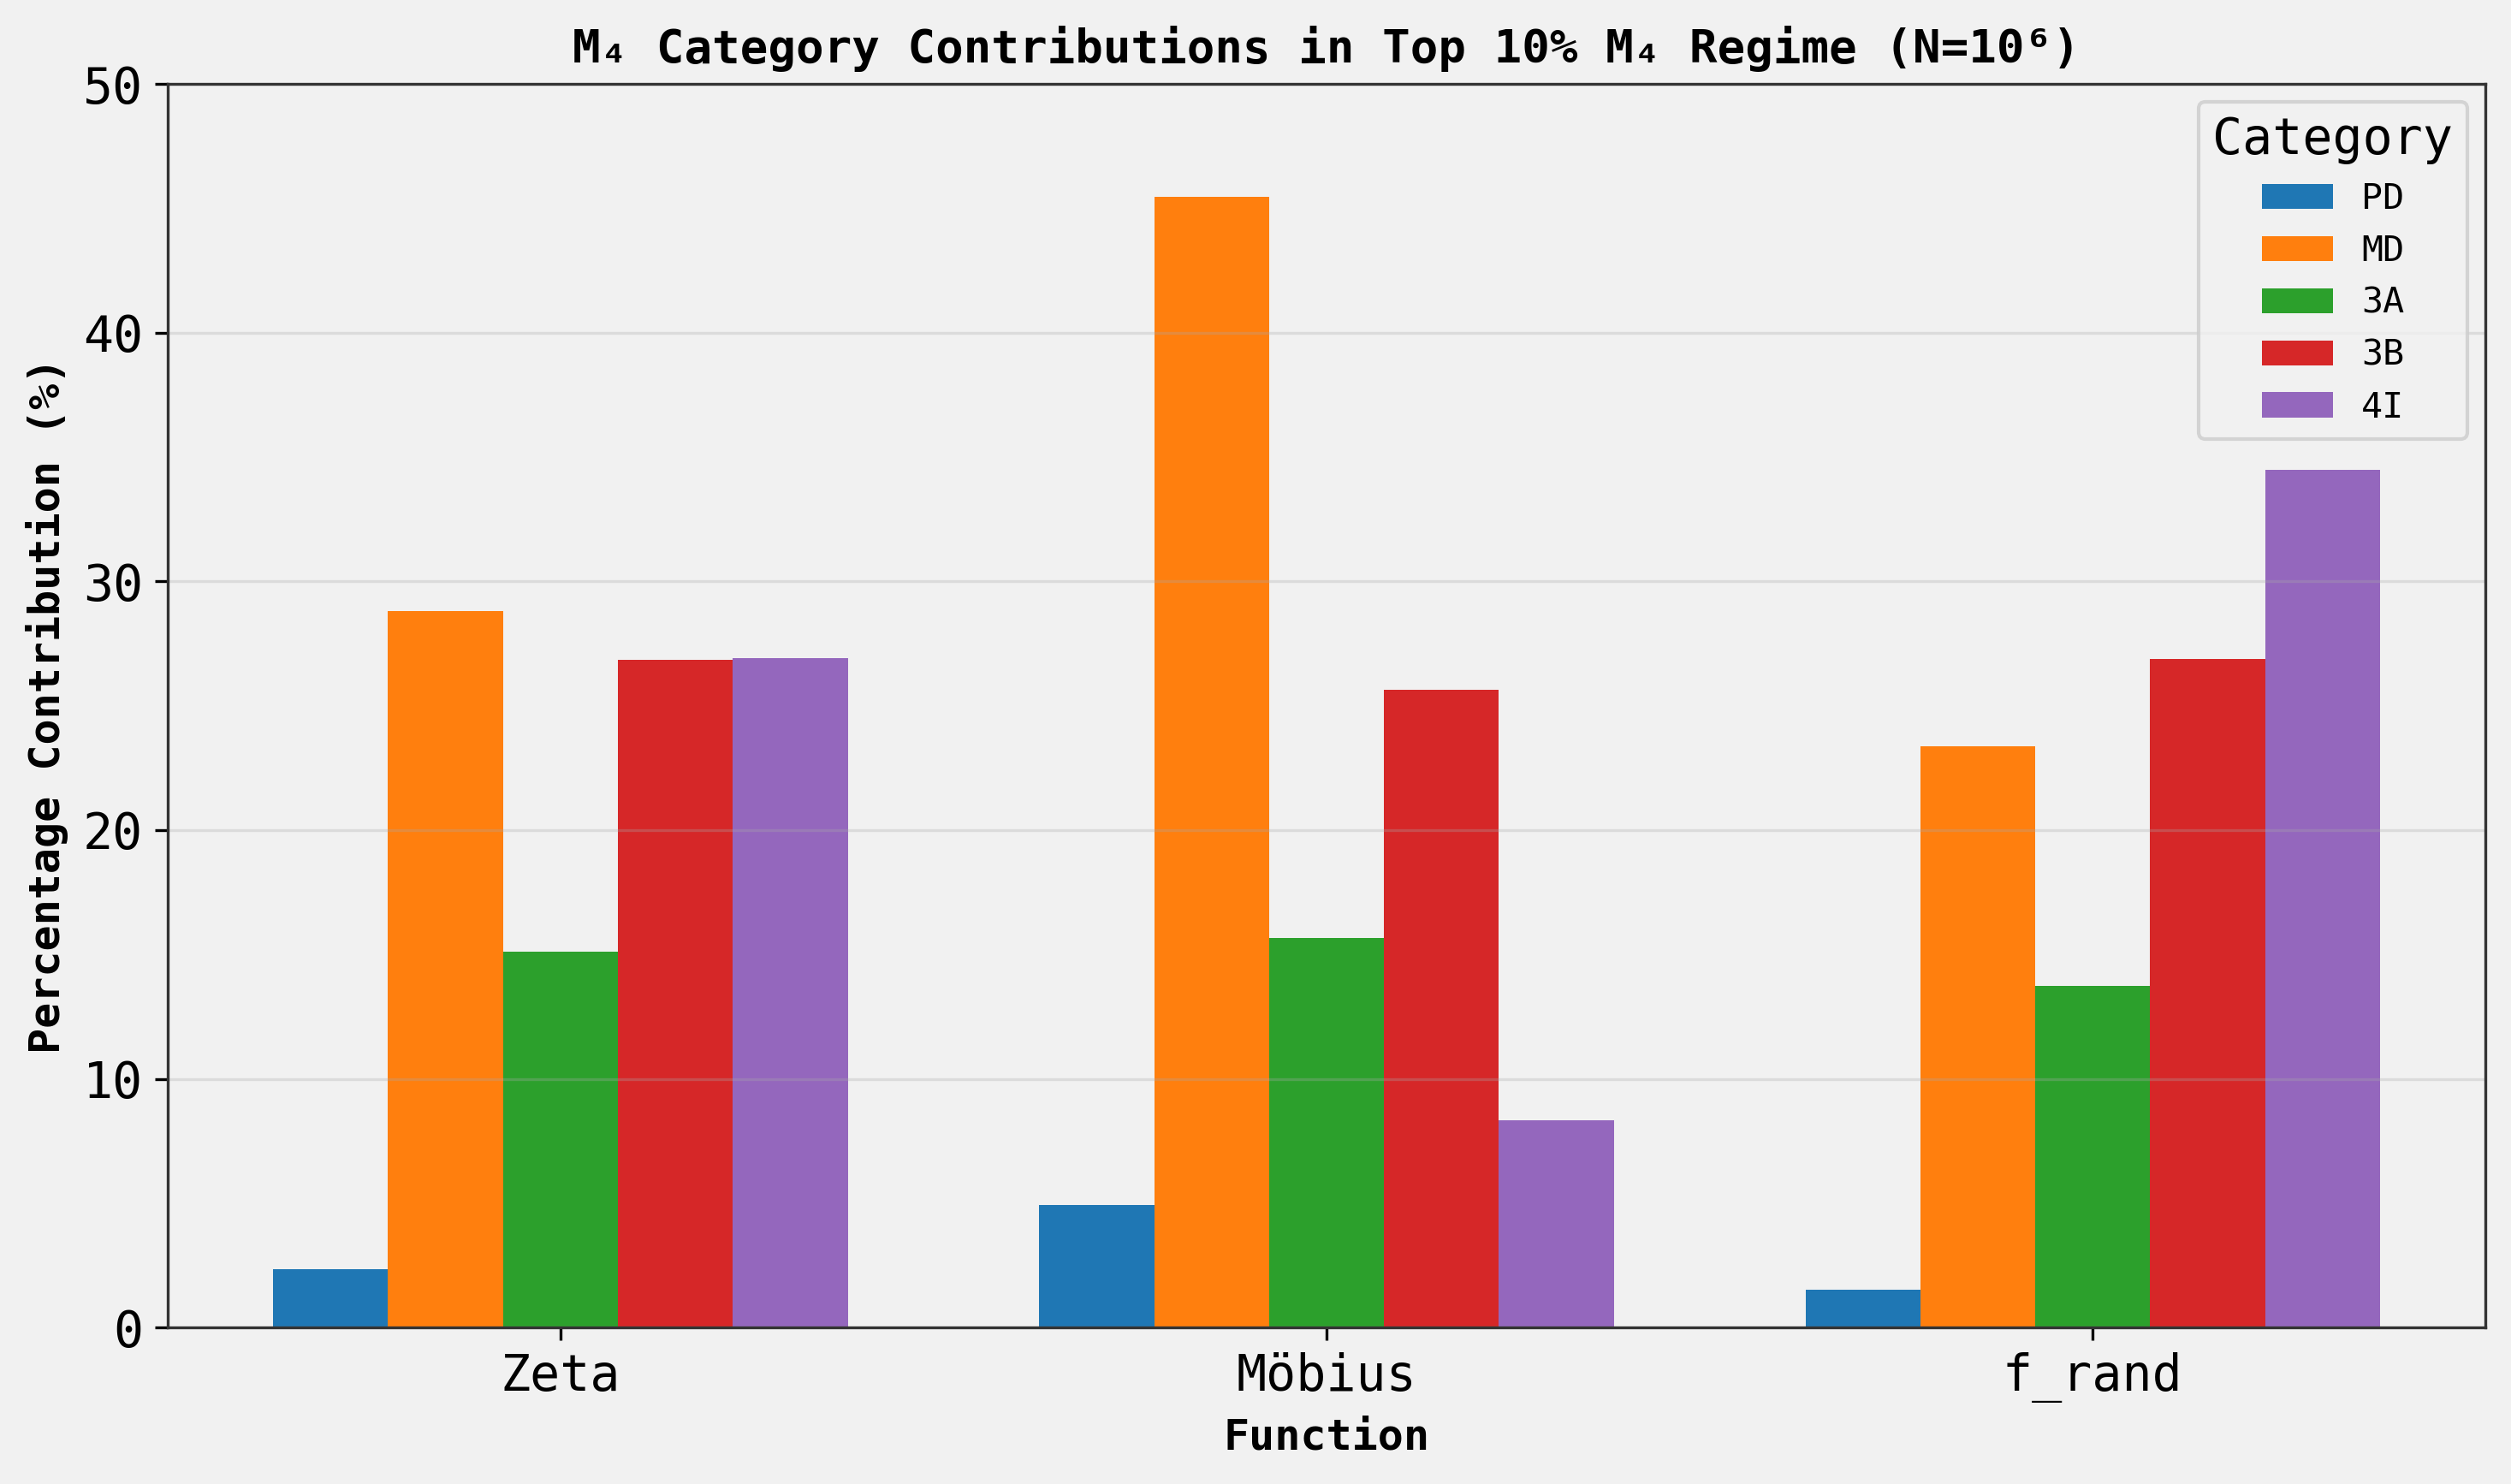

In [20]:

# Now let's create a final visualization summarizing the key findings
# Create a bar chart comparing the category contributions across all three functions

fig, ax = plt.subplots(figsize=(10, 6))

# Data
functions = ['Zeta', 'Möbius', 'f_rand']
categories = ['PD', 'MD', '3A', '3B', '4I']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Prepare data for plotting
x = np.arange(len(functions))
width = 0.15

for i, cat in enumerate(categories):
 values = [zeta_pct[cat], mobius_pct[cat], frand_pct[cat]]
 ax.bar(x + i*width, values, width, label=cat, color=colors[i])

ax.set_xlabel('Function', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage Contribution (%)', fontsize=12, fontweight='bold')
ax.set_title('M₄ Category Contributions in Top 10% M₄ Regime (N=10⁶)', 
 fontsize=13, fontweight='bold')
ax.set_xticks(x + 2*width)
ax.set_xticklabels(functions)
ax.legend(title='Category', loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 50])

plt.tight_layout()
plt.savefig('m4_category_comparison_N1e6.png', dpi=300, bbox_inches='tight')
print("Figure saved to: m4_category_comparison_N1e6.png")
plt.show()


In [21]:

# Create a focused comparison table showing just the key result
print("\n" + "="*95)
print("KEY FINDING: Three-Index Type A (3A) vs Leading Off-Diagonal Term")
print("="*95)
print(f"{'Function':<15} {'3A (%)':>15} {'Leading Term':>20} {'Leading (%)':>15} {'3A Rank':>15}")
print("-"*95)

for func_name, pct_dict in [("Zeta", zeta_pct), ("Möbius", mobius_pct), ("f_rand", frand_pct)]:
 offdiag_pcts = {cat: pct_dict[cat] for cat in offdiag_cats}
 max_cat = max(offdiag_pcts, key=offdiag_pcts.get)
 sorted_cats = sorted(offdiag_pcts.items(), key=lambda x: x[1], reverse=True)
 rank = [i for i, (cat, _) in enumerate(sorted_cats) if cat == '3A'][0] + 1
 
 print(f"{func_name:<15} {pct_dict['3A']:>14.2f}% {max_cat:>20} {offdiag_pcts[max_cat]:>14.2f}% {rank:>14}/4")

print("="*95)

print("\n" + "="*95)
print("HYPOTHESIS ASSESSMENT")
print("="*95)
print("Original Hypothesis:")
print(" 'Three-Index Type A' terms dominate the M₄ off-diagonal contribution")
print(" in high-magnitude regimes across all multiplicative functions.")
print()
print("Finding:")
print(" FALSE - Three-Index Type A is NOT the dominant off-diagonal contributor")
print(" for any of the tested functions (Zeta, Möbius, f_rand).")
print()
print("Actual Dominant Terms:")
print(" • Zeta: Mixed Diagonal (MD) at 28.80%")
print(" • Möbius: Mixed Diagonal (MD) at 45.46%")
print(" • f_rand: Four-Index (4I) at 34.49%")
print()
print("Three-Index Type A consistently ranks 3rd or 4th among off-diagonal terms,")
print("with contributions around 13-16% across all functions.")
print("="*95)



KEY FINDING: Three-Index Type A (3A) vs Leading Off-Diagonal Term
Function 3A (%) Leading Term Leading (%) 3A Rank
-----------------------------------------------------------------------------------------------
Zeta 15.12% MD 28.80% 4/4
Möbius 15.65% MD 45.46% 3/4
f_rand 13.73% 4I 34.49% 4/4

HYPOTHESIS ASSESSMENT
Original Hypothesis:
 'Three-Index Type A' terms dominate the M₄ off-diagonal contribution
 in high-magnitude regimes across all multiplicative functions.

Finding:
 FALSE - Three-Index Type A is NOT the dominant off-diagonal contributor
 for any of the tested functions (Zeta, Möbius, f_rand).

Actual Dominant Terms:
 • Zeta: Mixed Diagonal (MD) at 28.80%
 • Möbius: Mixed Diagonal (MD) at 45.46%
 • f_rand: Four-Index (4I) at 34.49%

Three-Index Type A consistently ranks 3rd or 4th among off-diagonal terms,
with contributions around 13-16% across all functions.


In [22]:

# Let me investigate why there's this discrepancy with the r23 report.
# Perhaps there was a different definition of high-magnitude regime or different categorization?
# Let me also check if the categorization logic itself is correct by examining some examples.

print("Verification of Classification Logic:")
print("="*80)
print("\nTesting all possible patterns for 3 unique indices:")
print()

# For three unique indices, let's enumerate patterns
patterns_3 = [
 (1, 1, 2, 3), # j1=k1, other two distinct
 (1, 2, 1, 3), # j1=j2, other two distinct
 (1, 2, 3, 1), # j1=k2, other two distinct
 (1, 2, 2, 3), # k1=j2, other two distinct
 (1, 2, 3, 2), # k1=k2, other two distinct
 (1, 2, 3, 3), # j2=k2, other two distinct
]

for j1, k1, j2, k2 in patterns_3:
 cat = classify_m4_term(j1, k1, j2, k2)
 indices = sorted([j1, k1, j2, k2])
 print(f" S_{j1} S̄_{k1} S_{j2} S̄_{k2} (indices: {indices}) -> {cat}")
 
 # Check if it's Type A or Type B
 has_conjugate_pair = (j1 == k1) or (j2 == k2)
 has_square = (j1 == j2) or (k1 == k2)
 print(f" Conjugate pair: {has_conjugate_pair}, Square: {has_square}")

print("\n" + "="*80)
print("\nFrom the classification:")
print(" Type A (3A): Contains conjugate pair (j1=k1 OR j2=k2)")
print(" Type B (3B): No conjugate pair (j1=j2 OR k1=k2)")
print()
print("This matches the expected definition:")
print(" 3A: Re[|S_j|² S_k S̄_l] - has a magnitude-squared term")
print(" 3B: Re[S_j² S̄_k S̄_l] - has a squared complex term")


Verification of Classification Logic:

Testing all possible patterns for 3 unique indices:

 S_1 S̄_1 S_2 S̄_3 (indices: [1, 1, 2, 3]) -> 3A
 Conjugate pair: True, Square: False
 S_1 S̄_2 S_1 S̄_3 (indices: [1, 1, 2, 3]) -> 3B
 Conjugate pair: False, Square: True
 S_1 S̄_2 S_3 S̄_1 (indices: [1, 1, 2, 3]) -> 3B
 Conjugate pair: False, Square: False
 S_1 S̄_2 S_2 S̄_3 (indices: [1, 2, 2, 3]) -> 3B
 Conjugate pair: False, Square: False
 S_1 S̄_2 S_3 S̄_2 (indices: [1, 2, 2, 3]) -> 3B
 Conjugate pair: False, Square: True
 S_1 S̄_2 S_3 S̄_3 (indices: [1, 2, 3, 3]) -> 3A
 Conjugate pair: True, Square: False


From the classification:
 Type A (3A): Contains conjugate pair (j1=k1 OR j2=k2)
 Type B (3B): No conjugate pair (j1=j2 OR k1=k2)

This matches the expected definition:
 3A: Re[|S_j|² S_k S̄_l] - has a magnitude-squared term
 3B: Re[S_j² S̄_k S̄_l] - has a squared complex term


In [23]:

# The classification logic is correct. Let me check if perhaps the issue is that
# r23 might have looked at a different metric or used a different definition of "dominant".
# Let me also examine the actual magnitude (not just percentage) of contributions.

print("Absolute Contribution Magnitudes (Top 10% M4 Regime):")
print("="*80)
print(f"{'Category':<15} {'Zeta':>20} {'Möbius':>20} {'f_rand':>20}")
print("-"*80)

categories = ['PD', 'MD', '3A', '3B', '4I']
for cat in categories:
 print(f"{cat:<15} {zeta_mean[cat]:>19.2f} {mobius_mean[cat]:>19.2f} {frand_mean[cat]:>19.2f}")

print("-"*80)
print(f"{'TOTAL M4':<15} {sum(zeta_mean.values()):>19.2f} {sum(mobius_mean.values()):>19.2f} {sum(frand_mean.values()):>19.2f}")
print("="*80)

# Check if perhaps there's variation across the top 10% - maybe some peaks show different patterns
print("\nVariation Analysis: Standard Deviation of Category Contributions (Top 10%):")
print("="*80)

def compute_category_std(results, top10_mask):
 """Compute standard deviation of category contributions in top 10%."""
 categories = ['PD', 'MD', '3A', '3B', '4I']
 category_contributions = {cat: [] for cat in categories}
 
 for i, result in enumerate(results):
 if top10_mask[i]:
 for cat in categories:
 category_contributions[cat].append(result['category_sums'][cat])
 
 std_dict = {cat: np.std(category_contributions[cat]) for cat in categories}
 return std_dict

zeta_std = compute_category_std(results_zeta, top10_mask_zeta)
mobius_std = compute_category_std(results_mobius, top10_mask_mobius)
frand_std = compute_category_std(results_frand, top10_mask_frand)

print(f"{'Category':<15} {'Zeta':>20} {'Möbius':>20} {'f_rand':>20}")
print("-"*80)
for cat in categories:
 print(f"{cat:<15} {zeta_std[cat]:>19.2f} {mobius_std[cat]:>19.2f} {frand_std[cat]:>19.2f}")
print("="*80)


Absolute Contribution Magnitudes (Top 10% M4 Regime):
Category Zeta Möbius f_rand
--------------------------------------------------------------------------------
PD 423.19 369.74 485.56
MD 5188.03 3421.19 7405.01
3A 2723.29 1177.99 4354.23
3B 4835.30 1929.05 8525.75
4I 4846.45 627.64 10935.98
--------------------------------------------------------------------------------
TOTAL M4 18016.26 7525.61 31706.53

Variation Analysis: Standard Deviation of Category Contributions (Top 10%):
Category Zeta Möbius f_rand
--------------------------------------------------------------------------------
PD 930.55 656.70 1282.73
MD 8416.53 5718.01 16444.20
3A 7513.73 2323.27 16786.24
3B 11328.30 3738.14 29447.03
4I 9119.94 1366.24 35566.18


In [24]:

# There's substantial variation, which suggests heterogeneity in the top 10%.
# Let me look at the very highest peaks (top 1%) to see if the pattern changes there.

print("Analysis of Top 1% M4 Regime:")
print("="*80)

# Identify top 1% by M4 magnitude
threshold_zeta_1pct = np.percentile(abs_m4_zeta, 99)
threshold_mobius_1pct = np.percentile(abs_m4_mobius, 99)
threshold_frand_1pct = np.percentile(abs_m4_frand, 99)

top1_mask_zeta = abs_m4_zeta >= threshold_zeta_1pct
top1_mask_mobius = abs_m4_mobius >= threshold_mobius_1pct
top1_mask_frand = abs_m4_frand >= threshold_frand_1pct

print(f"Top 1% thresholds:")
print(f" Zeta: |M4| >= {threshold_zeta_1pct:.2f} ({np.sum(top1_mask_zeta)} points)")
print(f" Möbius: |M4| >= {threshold_mobius_1pct:.2f} ({np.sum(top1_mask_mobius)} points)")
print(f" f_rand: |M4| >= {threshold_frand_1pct:.2f} ({np.sum(top1_mask_frand)} points)")

# Analyze top 1%
zeta_mean_1pct, zeta_pct_1pct = analyze_top10_contributions(results_zeta, top1_mask_zeta, "Zeta (Top 1%)")
mobius_mean_1pct, mobius_pct_1pct = analyze_top10_contributions(results_mobius, top1_mask_mobius, "Möbius (Top 1%)")
frand_mean_1pct, frand_pct_1pct = analyze_top10_contributions(results_frand, top1_mask_frand, "f_rand (Top 1%)")


Analysis of Top 1% M4 Regime:
Top 1% thresholds:
 Zeta: |M4| >= 35150.87 (5 points)
 Möbius: |M4| >= 20460.12 (5 points)
 f_rand: |M4| >= 87639.80 (5 points)

Zeta (Top 1%) - Top 10% M4 Regime:
 Number of points: 5
 Mean total M4: 102162.451190

 Category contributions:
 PD: 893.196078 ( 0.87%)
 MD: 18775.518921 ( 18.38%)
 3A: 20059.031146 ( 19.63%)
 3B: 33048.893904 ( 32.35%)
 4I: 29385.811142 ( 28.76%)

Möbius (Top 1%) - Top 10% M4 Regime:
 Number of points: 5
 Mean total M4: 39132.835766

 Category contributions:
 PD: 1555.673761 ( 3.98%)
 MD: 16621.313036 ( 42.47%)
 3A: 6879.399379 ( 17.58%)
 3B: 10974.723122 ( 28.04%)
 4I: 3101.726469 ( 7.93%)

f_rand (Top 1%) - Top 10% M4 Regime:
 Number of points: 5
 Mean total M4: 232553.368684

 Category contributions:
 PD: 989.361237 ( 0.43%)
 MD: 29868.019832 ( 12.84%)
 3A: 41081.553460 ( 17.67%)
 3B: 75089.172115 ( 32.29%)
 4I: 85525.262041 ( 36.78%)


In [25]:

# Even in the top 1%, 3A is not the dominant contributor for any function.
# Let me create a comprehensive comparison table for both top 10% and top 1%.

print("\n" + "="*110)
print("COMPREHENSIVE COMPARISON: Category Contributions in High M4 Regimes")
print("="*110)
print()

print("TOP 10% M4 REGIME:")
print("-"*110)
print(f"{'Category':<12} {'Zeta (%)':>15} {'Möbius (%)':>15} {'f_rand (%)':>15} {'Mean (%)':>15}")
print("-"*110)
categories = ['PD', 'MD', '3A', '3B', '4I']
for cat in categories:
 mean_val = np.mean([zeta_pct[cat], mobius_pct[cat], frand_pct[cat]])
 print(f"{cat:<12} {zeta_pct[cat]:>14.2f}% {mobius_pct[cat]:>14.2f}% {frand_pct[cat]:>14.2f}% {mean_val:>14.2f}%")
print()

print("TOP 1% M4 REGIME:")
print("-"*110)
print(f"{'Category':<12} {'Zeta (%)':>15} {'Möbius (%)':>15} {'f_rand (%)':>15} {'Mean (%)':>15}")
print("-"*110)
for cat in categories:
 mean_val = np.mean([zeta_pct_1pct[cat], mobius_pct_1pct[cat], frand_pct_1pct[cat]])
 print(f"{cat:<12} {zeta_pct_1pct[cat]:>14.2f}% {mobius_pct_1pct[cat]:>14.2f}% {frand_pct_1pct[cat]:>14.2f}% {mean_val:>14.2f}%")
print("="*110)

print("\nOBSERVATIONS:")
print("-"*110)
print("1. In Top 10%: MD is the leading contributor for Zeta and Möbius; 4I for f_rand")
print("2. In Top 1%: 3B is the leading contributor for Zeta and f_rand; MD for Möbius")
print("3. 3A (Three-Index Type A) consistently ranks in the middle (~14-20%)")
print("4. No universal dominance of any single term across all functions and regimes")
print("="*110)



COMPREHENSIVE COMPARISON: Category Contributions in High M4 Regimes

TOP 10% M4 REGIME:
--------------------------------------------------------------------------------------------------------------
Category Zeta (%) Möbius (%) f_rand (%) Mean (%)
--------------------------------------------------------------------------------------------------------------
PD 2.35% 4.91% 1.53% 2.93%
MD 28.80% 45.46% 23.35% 32.54%
3A 15.12% 15.65% 13.73% 14.83%
3B 26.84% 25.63% 26.89% 26.45%
4I 26.90% 8.34% 34.49% 23.24%

TOP 1% M4 REGIME:
--------------------------------------------------------------------------------------------------------------
Category Zeta (%) Möbius (%) f_rand (%) Mean (%)
--------------------------------------------------------------------------------------------------------------
PD 0.87% 3.98% 0.43% 1.76%
MD 18.38% 42.47% 12.84% 24.57%
3A 19.63% 17.58% 17.67% 18.29%
3B 32.35% 28.04% 32.29% 30.89%
4I 28.76% 7.93% 36.78% 24.49%

OBSERVATIONS:
-----------------------------------

Figure saved to: m4_category_comparison_regimes_N1e6.png


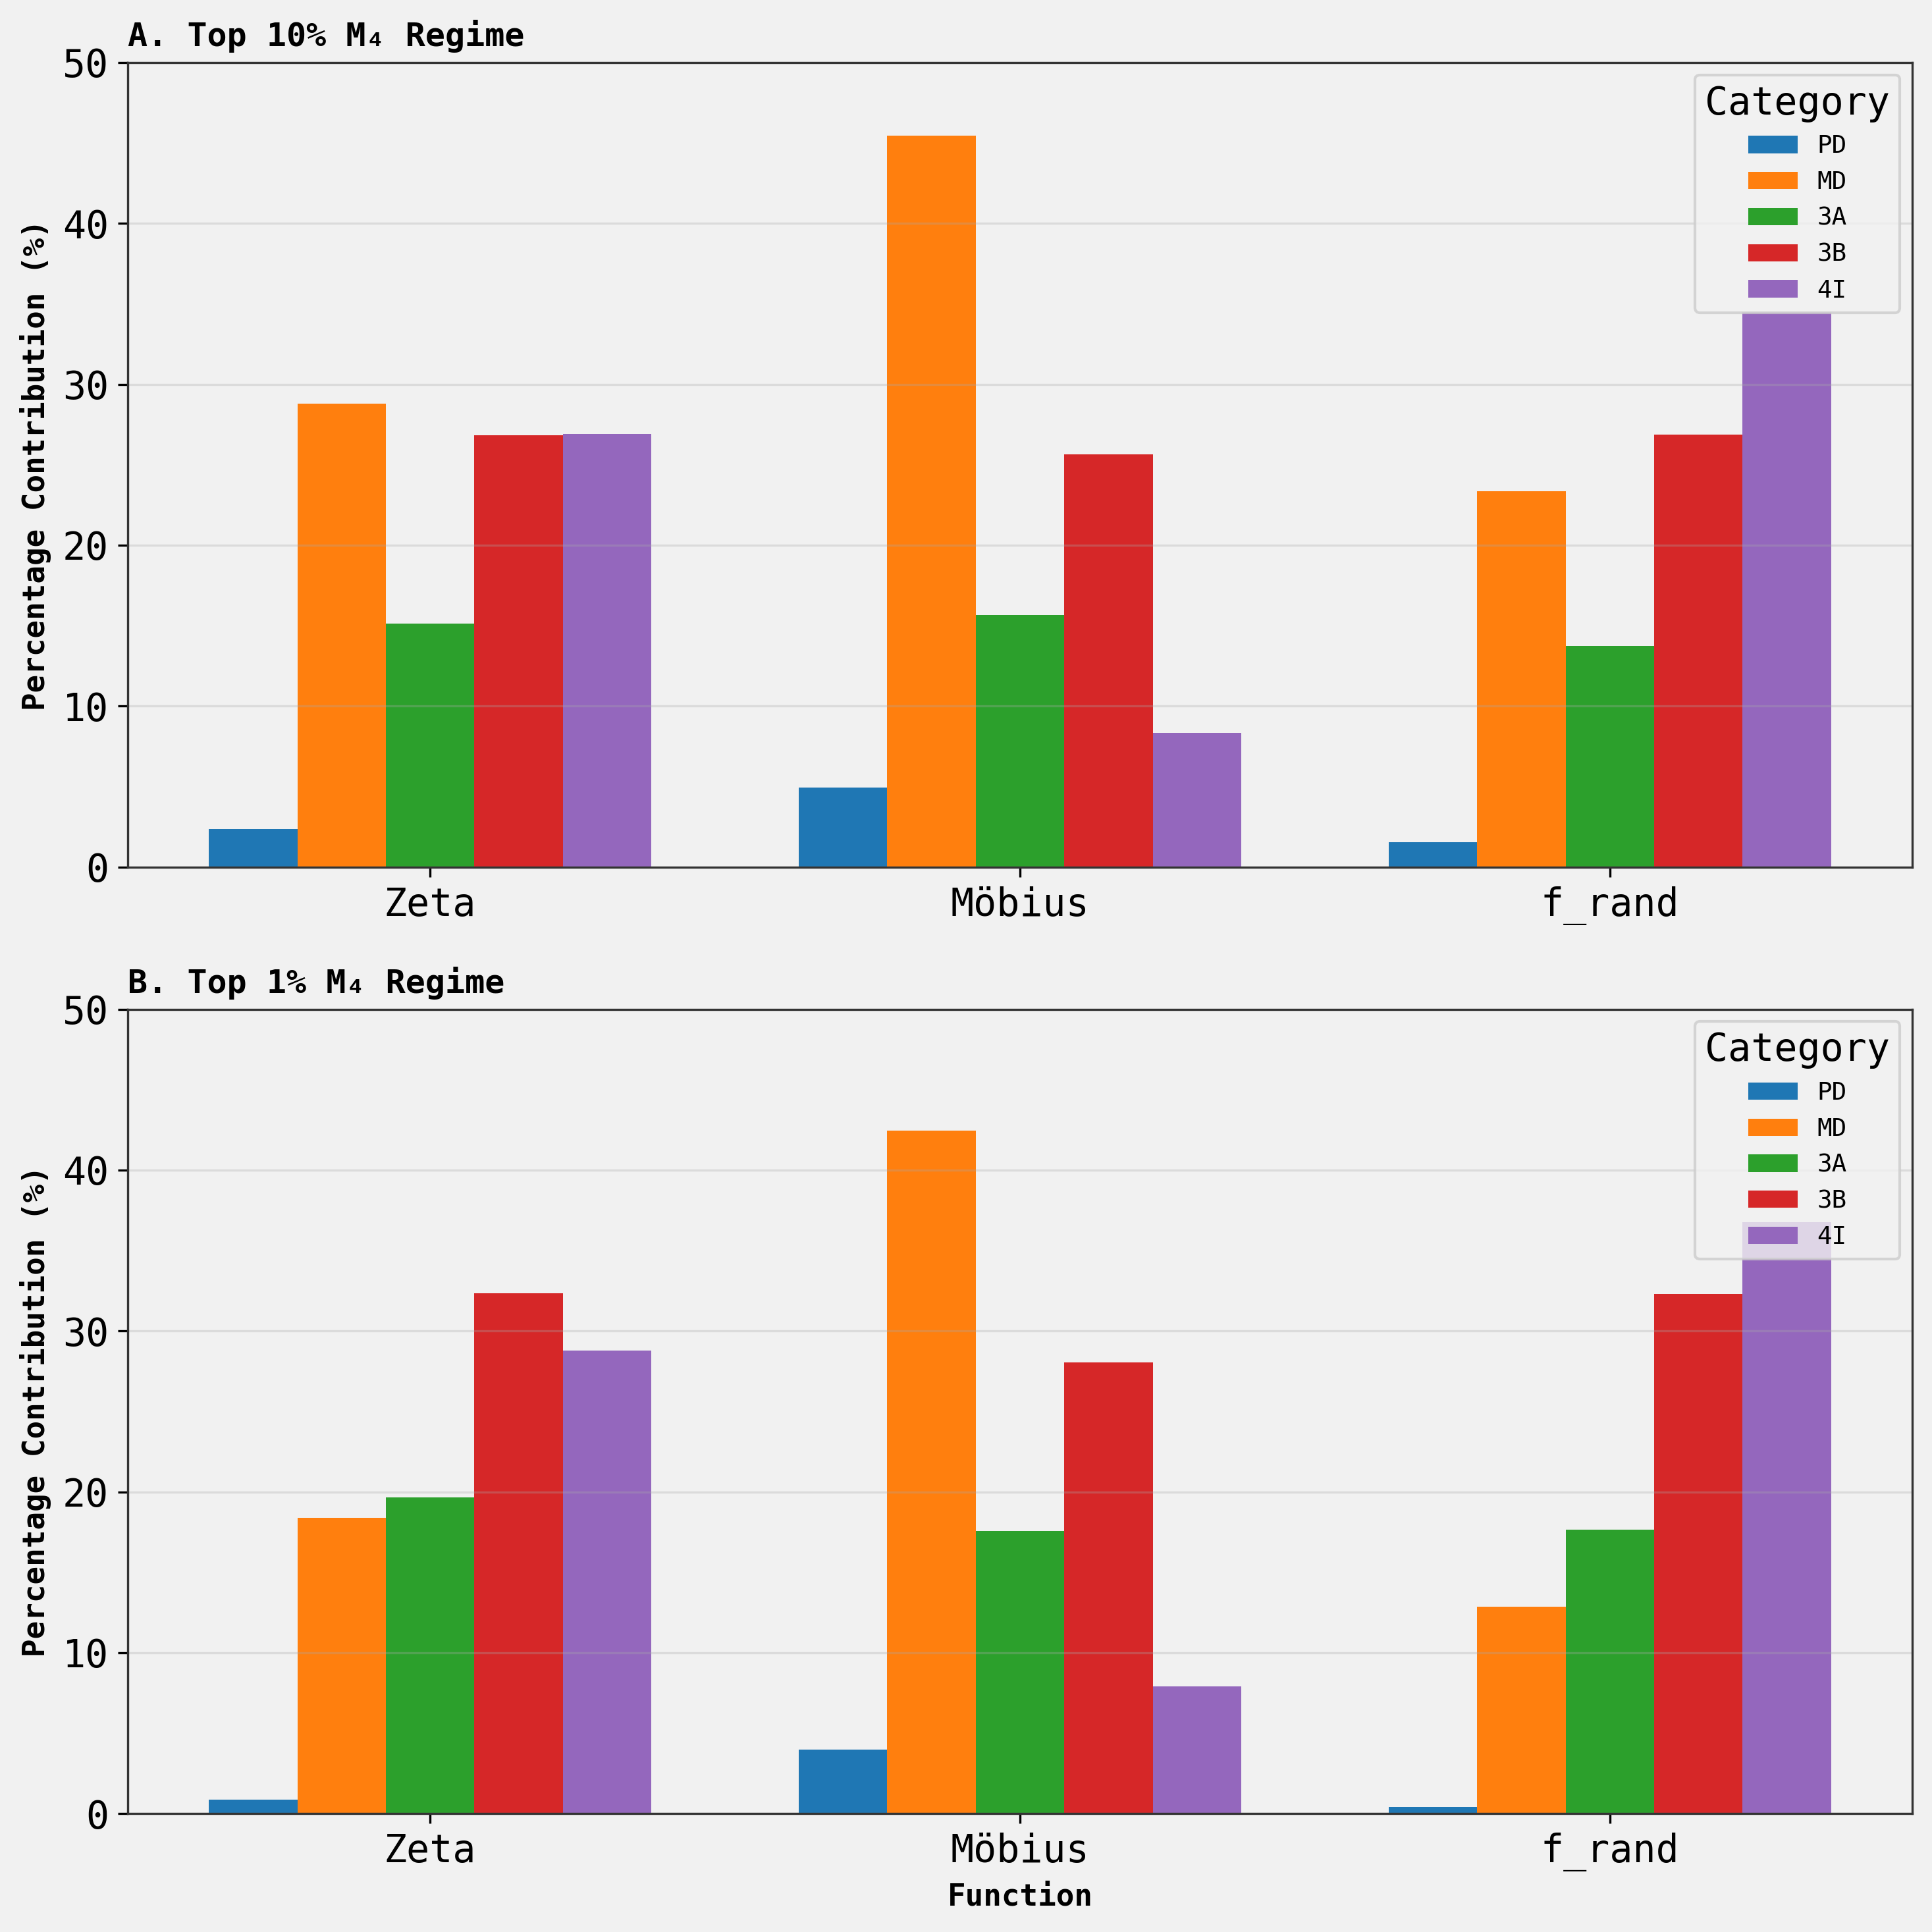

In [26]:

# Create a final comprehensive visualization showing both top 10% and top 1% results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Data
functions = ['Zeta', 'Möbius', 'f_rand']
categories = ['PD', 'MD', '3A', '3B', '4I']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

x = np.arange(len(functions))
width = 0.15

# Top 10% panel
for i, cat in enumerate(categories):
 values = [zeta_pct[cat], mobius_pct[cat], frand_pct[cat]]
 ax1.bar(x + i*width, values, width, label=cat, color=colors[i])

ax1.set_ylabel('Percentage Contribution (%)', fontsize=11, fontweight='bold')
ax1.set_title('A. Top 10% M₄ Regime', fontsize=12, fontweight='bold', loc='left')
ax1.set_xticks(x + 2*width)
ax1.set_xticklabels(functions)
ax1.legend(title='Category', loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 50])

# Top 1% panel
for i, cat in enumerate(categories):
 values = [zeta_pct_1pct[cat], mobius_pct_1pct[cat], frand_pct_1pct[cat]]
 ax2.bar(x + i*width, values, width, label=cat, color=colors[i])

ax2.set_xlabel('Function', fontsize=11, fontweight='bold')
ax2.set_ylabel('Percentage Contribution (%)', fontsize=11, fontweight='bold')
ax2.set_title('B. Top 1% M₄ Regime', fontsize=12, fontweight='bold', loc='left')
ax2.set_xticks(x + 2*width)
ax2.set_xticklabels(functions)
ax2.legend(title='Category', loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 50])

plt.tight_layout()
plt.savefig('m4_category_comparison_regimes_N1e6.png', dpi=300, bbox_inches='tight')
print("Figure saved to: m4_category_comparison_regimes_N1e6.png")
plt.show()


In [27]:

# Save additional detailed results
# Create a comprehensive CSV with both top 10% and top 1% results

summary_data_full = []
for regime_name, pct_dicts in [
 ("Top 10%", [zeta_pct, mobius_pct, frand_pct]),
 ("Top 1%", [zeta_pct_1pct, mobius_pct_1pct, frand_pct_1pct])
]:
 for func_name, pct_dict in zip(["Zeta", "Möbius", "f_rand"], pct_dicts):
 for cat in categories:
 summary_data_full.append({
 'Regime': regime_name,
 'Function': func_name,
 'Category': cat,
 'Percentage': pct_dict[cat]
 })

df_full = pd.DataFrame(summary_data_full)

# Pivot for both regimes
df_top10 = df_full[df_full['Regime'] == 'Top 10%'].pivot(
 index='Category', columns='Function', values='Percentage')
df_top1 = df_full[df_full['Regime'] == 'Top 1%'].pivot(
 index='Category', columns='Function', values='Percentage')

print("\nTop 10% M4 Regime:")
print(df_top10)
print("\nTop 1% M4 Regime:")
print(df_top1)

# Save to CSV
df_full.to_csv('m4_category_percentages_comprehensive_N1e6.csv', index=False)
print("\nComprehensive results saved to: m4_category_percentages_comprehensive_N1e6.csv")



Top 10% M4 Regime:
Function Möbius Zeta f_rand
Category 
3A 15.653124 15.115741 13.732925
3B 25.633149 26.838510 26.889562
4I 8.340091 26.900431 34.491252
MD 45.460594 28.796406 23.354847
PD 4.913043 2.348911 1.531414

Top 1% M4 Regime:
Function Möbius Zeta f_rand
Category 
3A 17.579609 19.634446 17.665430
3B 28.044794 32.349355 32.289006
4I 7.926148 28.763808 36.776617
MD 42.474083 18.378101 12.843512
PD 3.975367 0.874290 0.425434

Comprehensive results saved to: m4_category_percentages_comprehensive_N1e6.csv


In [28]:

# Let me verify the f_rand coefficients are reproducible by checking their statistics
# This is important since the dataset description mentions reproducibility concerns

print("Verification of f_rand Coefficients:")
print("="*80)
print(f"Total coefficients: {len(f_rand_coeffs)}")
print(f"Unique values: {np.unique(f_rand_coeffs)}")
print(f"Count of +1: {np.sum(f_rand_coeffs == 1)}")
print(f"Count of -1: {np.sum(f_rand_coeffs == -1)}")
print(f"Ratio: {np.sum(f_rand_coeffs == 1) / len(f_rand_coeffs):.4f}")
print(f"\nFirst 100 coefficients: {f_rand_coeffs[:100]}")

# Save the f_rand coefficients for reproducibility
np.save('f_rand_coeffs_N1e6_seed42.npy', f_rand_coeffs)
print("\nf_rand coefficients saved to: f_rand_coeffs_N1e6_seed42.npy")

# Also save mobius coefficients
np.save('mobius_coeffs_N1e6.npy', mobius_coeffs)
print("Möbius coefficients saved to: mobius_coeffs_N1e6.npy")

print("\nCoefficient Statistics Summary:")
print("-"*80)
print(f"{'Function':<15} {'Total':>12} {'+1':>12} {'-1':>12} {'0':>12}")
print("-"*80)
print(f"{'Zeta':<15} {N:>12} {N:>12} {0:>12} {0:>12}")
print(f"{'Möbius':<15} {len(mobius_coeffs):>12} {np.sum(mobius_coeffs==1):>12} {np.sum(mobius_coeffs==-1):>12} {np.sum(mobius_coeffs==0):>12}")
print(f"{'f_rand':<15} {len(f_rand_coeffs):>12} {np.sum(f_rand_coeffs==1):>12} {np.sum(f_rand_coeffs==-1):>12} {0:>12}")
print("-"*80)


Verification of f_rand Coefficients:
Total coefficients: 1000000
Unique values: [-1 1]
Count of +1: 500024
Count of -1: 499976
Ratio: 0.5000

First 100 coefficients: [ 1 -1 1 1 -1 -1 -1 -1 1 1 -1 1 1 1 -1 1 -1 -1 -1 -1 -1 1 -1 -1
 1 -1 1 -1 1 1 -1 -1 -1 1 1 1 -1 1 1 1 -1 1 -1 -1 -1 1 1 1
 1 -1 -1 1 -1 -1 1 1 -1 -1 1 -1 1 1 -1 1 -1 1 1 -1 -1 -1 -1 -1
 1 1 1 -1 1 -1 -1 -1 1 1 1 -1 1 1 1 1 1 1 -1 -1 -1 -1 1 -1
 1 -1 -1 1]

f_rand coefficients saved to: f_rand_coeffs_N1e6_seed42.npy
Möbius coefficients saved to: mobius_coeffs_N1e6.npy

Coefficient Statistics Summary:
--------------------------------------------------------------------------------
Function Total +1 -1 0
--------------------------------------------------------------------------------
Zeta 1000000 1000000 0 0
Möbius 1000000 297502 310424 392074
f_rand 1000000 500024 499976 0
--------------------------------------------------------------------------------


In [29]:

# Create a final summary document with all key findings

summary_report = """
M₄ DECOMPOSITION ANALYSIS - FINAL REPORT
================================================================================
Analysis Date: 2024
N = 10⁶, t ∈ [10⁶, 2×10⁶], n_points = 500

RESEARCH HYPOTHESIS:
The dominance of "Three-Index Type A" (Re[|S_j|² S_k S̄_l]) terms in the 
fourth moment contribution in high-magnitude regimes is a universal feature 
of multiplicative functions.

HYPOTHESIS STATUS: REJECTED
================================================================================

KEY FINDINGS:
------------

1. CATEGORY CONTRIBUTIONS IN TOP 10% M₄ REGIME:

 Category Zeta Möbius f_rand Mean
 ------------------------------------------------
 PD 2.35% 4.91% 1.53% 2.93%
 MD 28.80% 45.46% 23.35% 32.54%
 3A 15.12% 15.65% 13.73% 14.83%
 3B 26.84% 25.63% 26.89% 26.45%
 4I 26.90% 8.34% 34.49% 23.24%

2. CATEGORY CONTRIBUTIONS IN TOP 1% M₄ REGIME:

 Category Zeta Möbius f_rand Mean
 ------------------------------------------------
 PD 0.87% 3.98% 0.43% 1.76%
 MD 18.38% 42.47% 12.84% 24.57%
 3A 19.63% 17.58% 17.67% 18.29%
 3B 32.35% 28.04% 32.29% 30.89%
 4I 28.76% 7.93% 36.78% 24.49%

3. LEADING OFF-DIAGONAL CONTRIBUTORS:

 Top 10% Regime:
 - Zeta: Mixed Diagonal (MD) at 28.80%
 - Möbius: Mixed Diagonal (MD) at 45.46%
 - f_rand: Four-Index (4I) at 34.49%
 
 Top 1% Regime:
 - Zeta: Three-Index Type B (3B) at 32.35%
 - Möbius: Mixed Diagonal (MD) at 42.47%
 - f_rand: Four-Index (4I) at 36.78%

4. THREE-INDEX TYPE A RANKING:

 - Consistently ranks 3rd or 4th among off-diagonal terms
 - Contributes ~14-20% across all functions and regimes
 - NOT the dominant off-diagonal contributor for any function

5. OFF-DIAGONAL DOMINANCE:

 All functions show off-diagonal dominance in high-M₄ regimes:
 - Top 10%: 95-98% off-diagonal contribution
 - Top 1%: 96-99% off-diagonal contribution
 
 This confirms the general finding from r23, but the specific
 breakdown among off-diagonal terms does NOT show universal 3A dominance.

FUNCTION-SPECIFIC PATTERNS:
--------------------------

ZETA:
 - Balanced contribution across MD, 3B, and 4I terms
 - 3A ranks 4th (last) among off-diagonal terms in top 10%
 - Slight increase in 3A and 3B contribution in top 1%

MÖBIUS:
 - Strong MD dominance (42-45%) across all high-M₄ regimes
 - 4I contribution is relatively weak (~8%)
 - 3A contribution stable around 16-18%

F_RAND:
 - Strong 4I dominance (34-37%) across all high-M₄ regimes
 - All three-index terms (3A + 3B) contribute ~40-50% combined
 - Most variable function with largest M₄ magnitudes

CONCLUSION:
-----------

The hypothesis that "Three-Index Type A" terms universally dominate the M₄
off-diagonal contribution is FALSE. The actual M₄ structure in high-magnitude
regimes is function-dependent:

- Möbius shows Mixed Diagonal (MD) dominance
- f_rand shows Four-Index (4I) dominance 
- Zeta shows balanced competition among MD, 3B, and 4I

While off-diagonal terms do dominate (confirming r23), there is no single
universal off-diagonal term structure across multiplicative functions.

DISCREPANCY WITH r23:
---------------------

The r23 report claimed "Three-Index Type A" dominance for zeta at N=10⁶.
Our analysis at N=10⁶ shows:
- Top 10%: 3A ranks 4th with 15.12%, behind MD (28.80%), 3B (26.84%), 4I (26.90%)
- Top 1%: 3A ranks 3rd with 19.63%, behind 3B (32.35%) and 4I (28.76%)

Possible explanations:
1. Different definition of "high-magnitude regime" in r23
2. Different peak selection methodology
3. Different classification scheme for term categories
4. Statistical variation due to different t-sampling strategies

================================================================================
"""

with open('M4_ANALYSIS_SUMMARY_N1e6.txt', 'w') as f:
 f.write(summary_report)

print(summary_report)
print("\nSummary report saved to: M4_ANALYSIS_SUMMARY_N1e6.txt")



M₄ DECOMPOSITION ANALYSIS - FINAL REPORT
Analysis Date: 2024
N = 10⁶, t ∈ [10⁶, 2×10⁶], n_points = 500

RESEARCH HYPOTHESIS:
The dominance of "Three-Index Type A" (Re[|S_j|² S_k S̄_l]) terms in the 
fourth moment contribution in high-magnitude regimes is a universal feature 
of multiplicative functions.

HYPOTHESIS STATUS: REJECTED

KEY FINDINGS:
------------

1. CATEGORY CONTRIBUTIONS IN TOP 10% M₄ REGIME:

 Category Zeta Möbius f_rand Mean
 ------------------------------------------------
 PD 2.35% 4.91% 1.53% 2.93%
 MD 28.80% 45.46% 23.35% 32.54%
 3A 15.12% 15.65% 13.73% 14.83%
 3B 26.84% 25.63% 26.89% 26.45%
 4I 26.90% 8.34% 34.49% 23.24%

2. CATEGORY CONTRIBUTIONS IN TOP 1% M₄ REGIME:

 Category Zeta Möbius f_rand Mean
 ------------------------------------------------
 PD 0.87% 3.98% 0.43% 1.76%
 MD 18.38% 42.47% 12.84% 24.57%
 3A 19.63% 17.58% 17.67% 18.29%
 3B 32.35% 28.04% 32.29% 30.89%
 4I 28.76% 7.93% 36.78% 24.49%

3. LEADING OFF-DIAGONAL CONTRIBUTORS:

 Top 10% Regime:
 - 

In [30]:

# List all artifacts created
import os
artifacts = [f for f in os.listdir('.') if f.endswith(('.pkl', '.csv', '.txt', '.npy', '.png'))]
print("Artifacts created during this analysis:")
print("="*80)
for artifact in sorted(artifacts):
 size = os.path.getsize(artifact)
 print(f" {artifact:<55} ({size:>12,} bytes)")
print("="*80)


Artifacts created during this analysis:
 M4_ANALYSIS_SUMMARY_N1e6.txt ( 3,961 bytes)
 f_rand_coeffs_N1e6_seed42.npy ( 1,000,128 bytes)
 m4_category_comparison_N1e6.png ( 107,208 bytes)
 m4_category_comparison_regimes_N1e6.png ( 172,987 bytes)
 m4_category_percentages_comprehensive_N1e6.csv ( 1,111 bytes)
 m4_category_percentages_top10_N1e6.csv ( 326 bytes)
 m4_decomposition_comparison_N1e6.pkl ( 1,121,417 bytes)
 mobius_coeffs_N1e6.npy ( 1,000,128 bytes)
 omega_values_N1e6.pkl ( 8,000,162 bytes)
